## Step 1 : Download data of Interest

We will use data dowloaded from yfinance. The data we download is from the Hotel industry. We download 5 different stocks for this project which are : \
    - Booking.com \
    - Hyatt \
    - Hilton \
    - Mariott \
    - IHG

In [26]:
from main import Fetch_Data
from main import Select_Pair
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_5_series
import pandas as pd

In [2]:
start_date = '2010-01-01'
end_date = '2025-02-01'
tickers = ['IHG', 'HLT', 'MAR', 'BKNG', 'H']

In [3]:
fetcher = Fetch_Data(start_date,end_date,tickers)
data = fetcher.download_data()

/Users/mpecaut/Empirical-Methods-In-Finance/Project1/main.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.tickers, start = self.start_date, end = self.end_date)
[*********************100%***********************]  5 of 5 completed


In [4]:
data = data['Close']

In [5]:
data

Ticker,BKNG,H,HLT,IHG,MAR
Date,,,,,
2010-01-04,5.395237,3.367404,NaN,2.537660,3.090992
2010-01-05,5.406780,3.368738,NaN,2.530749,3.096767
2010-01-06,5.373207,3.359361,NaN,2.526580,3.099641
2010-01-07,5.359650,3.365065,NaN,2.536971,3.103580
2010-01-08,5.360020,3.359025,NaN,2.556085,3.105722
...,...,...,...,...,...
2025-01-27,8.442659,5.045439,5.517589,4.849532,5.651489
2025-01-28,8.444650,5.058750,5.533243,4.867816,5.653535
2025-01-29,8.452555,5.054884,5.534307,4.872074,5.657063


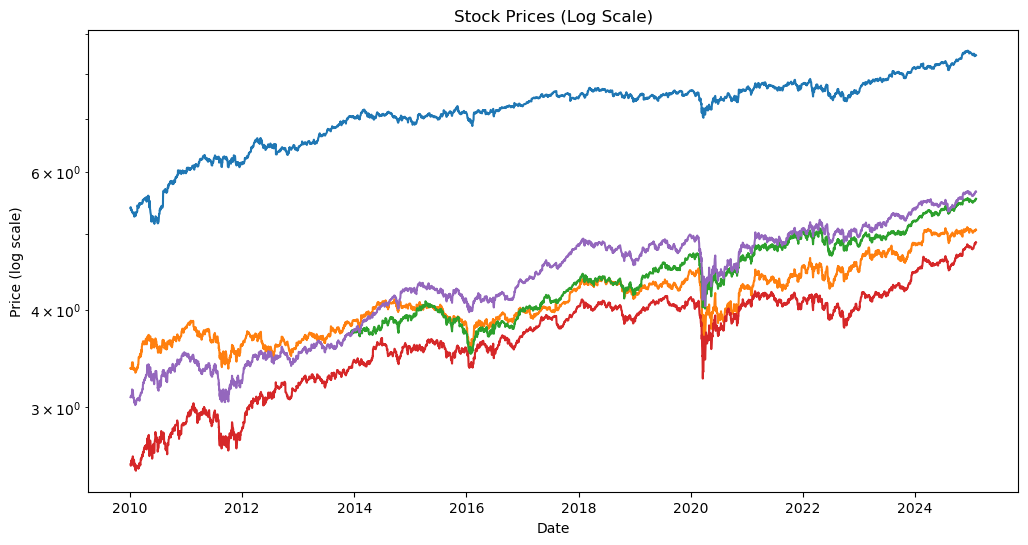

In [6]:
plot_5_series(data,'Stock Prices (Log Scale)','log', 'Date', 'Price (log scale)')

## Stationarity 

Stationarity means that the 2 first moments are constant through time, i.e mean and variance exhibit no time-dependence. Ultimately, if my asset is stationary, it means it exhibits no trends or seasonal effects. It is important to differentiate the cointegration from the correlation. Two assets are correlated in the sense that if one moves up, the other will certainly also move up by some amount. However, this might not imply that the spread between those 2 assets is constant. Indeed, it might even diverge. This is where cointegration comes into play. If two assets are cointegrated, then the spread (the price difference between the 2 assets) will remain constant through time. This implies that if the spread diverges (goes above or below its normal level), in theory, it should not be long before this value comes back to its average level. This is what we will exploit later on.

In [7]:
data = np.log(data)
data

Ticker,BKNG,H,HLT,IHG,MAR
Date,,,,,
2010-01-04,1.685517,1.214142,NaN,0.931242,1.128492
2010-01-05,1.687654,1.214538,NaN,0.928515,1.130359
2010-01-06,1.681425,1.211751,NaN,0.926867,1.131286
2010-01-07,1.678899,1.213447,NaN,0.930971,1.132556
2010-01-08,1.678968,1.211651,NaN,0.938477,1.133246
...,...,...,...,...,...
2025-01-27,2.133297,1.618485,1.707941,1.578882,1.731919
2025-01-28,2.133533,1.621119,1.710774,1.582645,1.732281
2025-01-29,2.134469,1.620355,1.710966,1.583520,1.732905


In [ ]:
pairselect = Select_Pair(data)
permut = pairselect.permutations()
most_coint_pair = pairselect.are_cointegrated()

score    pvalue
BKNG H    -3.042901  0.100357
     HLT  -2.784746  0.170586
     IHG  -4.575001  0.000920
     MAR  -3.141128  0.080337
H    BKNG -2.584901  0.242961
     HLT  -2.081202  0.486196
     IHG  -2.403248  0.323318
     MAR  -2.523847  0.268654
HLT  BKNG -2.608723  0.233330
     H    -2.113516  0.469304
     IHG  -2.417120  0.316790
     MAR  -2.864921  0.145900
IHG  BKNG -4.347626  0.002156
     H    -2.458665  0.297597
     HLT  -2.542856  0.260502
     MAR  -3.432506  0.038866
MAR  BKNG -2.707045  0.197055
     H    -2.381612  0.333613
     HLT  -3.322003  0.051782
     IHG  -3.289200  0.056234